In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR

results_table = []

def evaluate_and_plot(model_name, dataset_name, remarks, X_train, X_test, y_train, y_test, model, color):
    # Predict
    y_pred_test = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)
    
    # Log to table
    results_table.append({
        "Dataset": dataset_name,
        "Model": model_name,
        "Remarks": remarks,
        "MSE": round(mse, 3),
        "R2 Score": round(r2, 3)
    })
    
    # Generate a smooth line for plotting the curve
    X_plot = np.linspace(X_train.min()-0.5, X_train.max()+0.5, 200).reshape(-1, 1)
    y_plot_pred = model.predict(X_plot)
    
    # Plotting
    plt.figure(figsize=(7, 4))
    plt.scatter(X_train, y_train, color='gold', edgecolor='black', s=40, alpha=0.6, label='Training Data')
    plt.scatter(X_test, y_test, color='red', edgecolor='black', s=40, label='Test Data')
    plt.plot(X_plot, y_plot_pred, color=color, linewidth=2.5, label=f'Fit (R²: {r2:.2f})')
    
    plt.title(f"{model_name} | {remarks}")
    plt.xlabel("X"); plt.ylabel("y")
    plt.ylim(y_train.min()-1, y_train.max()+1) # Keep axes stable
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# --- GENERATE OUR TWO DATASETS ---
np.random.seed(42)

# Dataset 1: Linear
X_lin = 2 * np.random.rand(80, 1)
y_lin = (4 + 3 * X_lin + np.random.randn(80, 1) * 0.5).ravel()
X_train_L, X_test_L, y_train_L, y_test_L = train_test_split(X_lin, y_lin, test_size=0.25, random_state=42)

# Dataset 2: Non-Linear (Sine Wave with higher noise to force overfitting)
X_nl = np.sort(5 * np.random.rand(60, 1), axis=0)
y_nl = np.sin(X_nl).ravel() + np.random.normal(0, 0.4, X_nl.shape[0])
X_train_NL, X_test_NL, y_train_NL, y_test_NL = train_test_split(X_nl, y_nl, test_size=0.25, random_state=42)

## 1. The Baseline: Linear Data
If the underlying data is linear, a simple Linear Regression is all we need.

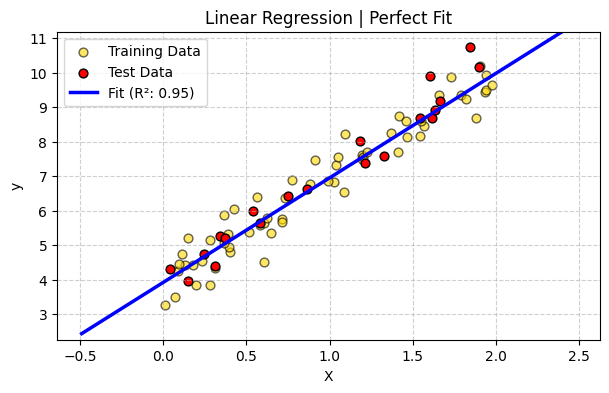

In [3]:
# Initialize
lin_reg = LinearRegression()
lin_reg.fit(X_train_L, y_train_L)

evaluate_and_plot("Linear Regression", "Linear Dataset", "Perfect Fit", 
                  X_train_L, X_test_L, y_train_L, y_test_L, lin_reg, "blue")

## 2. Tuning Hyperparameters: The Polynomial Degree
Now we apply models to our `Non-Linear Dataset`. 
We will change the `degree` hyperparameter to manually observe Underfitting (Degree 1), a Perfect Fit (Degree 3), and extreme Overfitting (Degree 15).

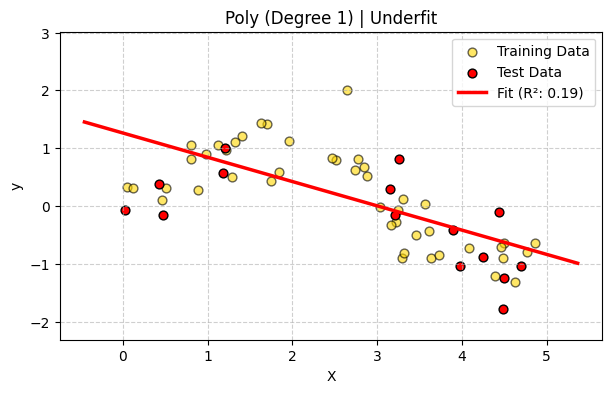

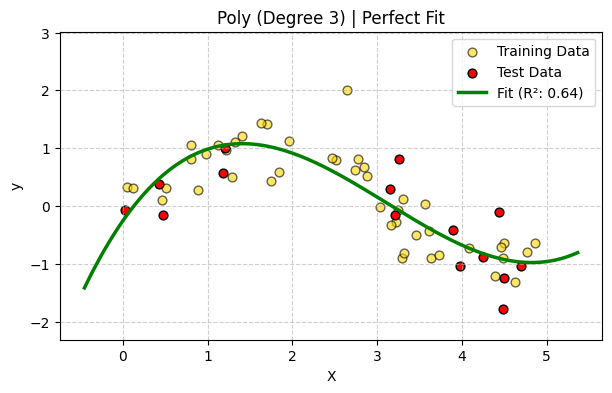

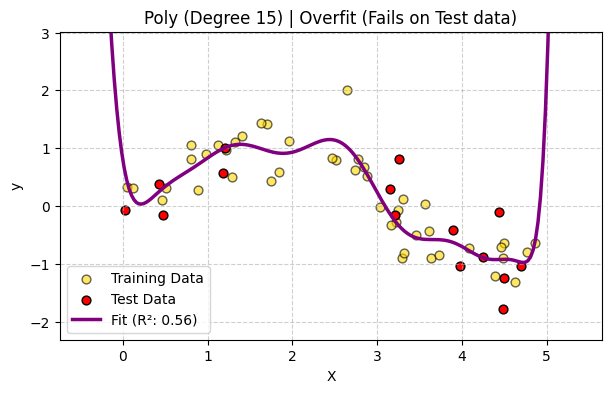

In [4]:
# 1. Underfitting (Degree 1 is just a straight line)
poly_1 = make_pipeline(PolynomialFeatures(degree=1), LinearRegression())
poly_1.fit(X_train_NL, y_train_NL)
evaluate_and_plot("Poly (Degree 1)", "Non-Linear Dataset", "Underfit", 
                  X_train_NL, X_test_NL, y_train_NL, y_test_NL, poly_1, "red")

# 2. Perfect Fit (Degree 3 captures the curve gracefully)
poly_3 = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
poly_3.fit(X_train_NL, y_train_NL)
evaluate_and_plot("Poly (Degree 3)", "Non-Linear Dataset", "Perfect Fit", 
                  X_train_NL, X_test_NL, y_train_NL, y_test_NL, poly_3, "green")

# 3. Overfitting (Degree 15 chases the noise, causing the Test R2 to crash)
poly_15 = make_pipeline(PolynomialFeatures(degree=15), LinearRegression())
poly_15.fit(X_train_NL, y_train_NL)
evaluate_and_plot("Poly (Degree 15)", "Non-Linear Dataset", "Overfit (Fails on Test data)", 
                  X_train_NL, X_test_NL, y_train_NL, y_test_NL, poly_15, "purple")

## 3. Taming the Overfit: Regularization
Degree 15 was a disaster. But what if we *have* to use a highly complex model? We can use Regularization (L1/L2 penalties) to shrink the coefficients and smooth out the curve.

/Users/cs/Desktop/AI_HandsOn_Course/myvenv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.0624401798828354e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


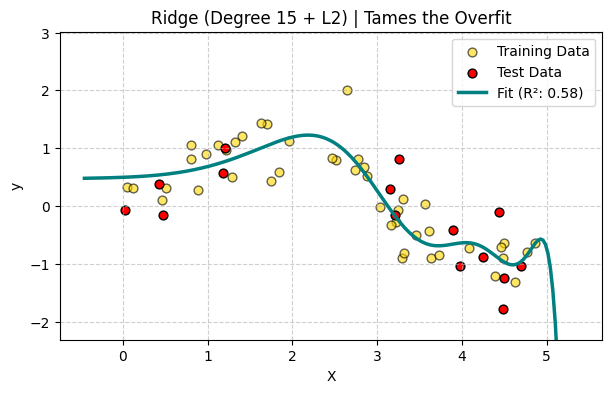

/Users/cs/Desktop/AI_HandsOn_Course/myvenv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.852e+00, tolerance: 2.955e-03
  model = cd_fast.enet_coordinate_descent(


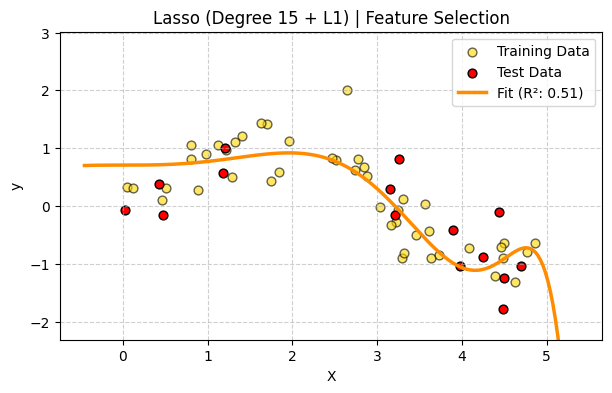

In [8]:
# Apply Ridge (L2 Penalty) to the Degree 15 features
ridge_15 = make_pipeline(PolynomialFeatures(degree=15), Ridge(alpha=10.0))
ridge_15.fit(X_train_NL, y_train_NL)
evaluate_and_plot("Ridge (Degree 15 + L2)", "Non-Linear Dataset", "Tames the Overfit", 
                  X_train_NL, X_test_NL, y_train_NL, y_test_NL, ridge_15, "teal")

# Apply Lasso (L1 Penalty) to the Degree 15 features
lasso_15 = make_pipeline(PolynomialFeatures(degree=15), Lasso(alpha=0.1, max_iter = 10000))
lasso_15.fit(X_train_NL, y_train_NL)
evaluate_and_plot("Lasso (Degree 15 + L1)", "Non-Linear Dataset", "Feature Selection", 
                  X_train_NL, X_test_NL, y_train_NL, y_test_NL, lasso_15, "darkorange")

## 4. Support Vector Regression (SVR)
Instead of guessing the right Polynomial degree, SVR uses the Kernel Trick to automatically map complex, non-linear relationships. Let's tweak the `gamma` hyperparameter (which controls how "tight" the margins are).

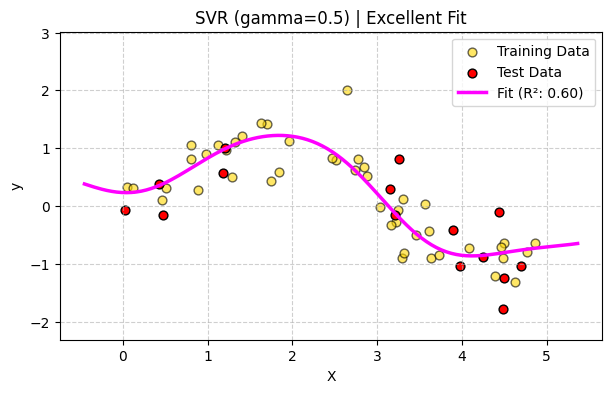

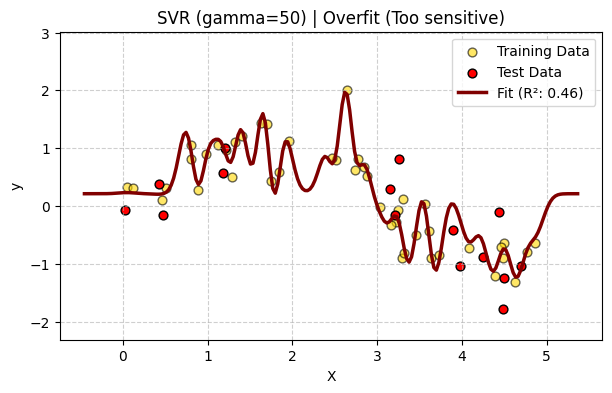

In [10]:
# SVR with a balanced Gamma
svr_balanced = SVR(kernel = 'rbf', C = 10, gamma = 0.5)
svr_balanced.fit(X_train_NL, y_train_NL)
evaluate_and_plot("SVR (gamma=0.5)", "Non-Linear Dataset", "Excellent Fit", 
                  X_train_NL, X_test_NL, y_train_NL, y_test_NL, svr_balanced, "magenta")

# SVR with a massive Gamma (will overfit the training data drastically)
svr_overfit = SVR(kernel = 'rbf', C = 10, gamma = 50)
svr_overfit.fit(X_train_NL, y_train_NL)
evaluate_and_plot("SVR (gamma=50)", "Non-Linear Dataset", "Overfit (Too sensitive)", 
                  X_train_NL, X_test_NL, y_train_NL, y_test_NL, svr_overfit, "maroon")

In [11]:
# Display the beautiful comparison table
df_results = pd.DataFrame(results_table)
display(df_results)

,Dataset,Model,Remarks,MSE,R2 Score
0,Linear Dataset,Linear Regression,Perfect Fit,0.222,0.948
1,Non-Linear Dataset,Poly (Degree 1),Underfit,0.493,0.189
2,Non-Linear Dataset,Poly (Degree 3),Perfect Fit,0.218,0.641
3,Non-Linear Dataset,Poly (Degree 15),Overfit (Fails on Test data),0.270,0.556
4,Non-Linear Dataset,Ridge (Degree 15 + L2),Tames the Overfit,0.256,0.578
5,Non-Linear Dataset,Lasso (Degree 15 + L1),Feature Selection,0.288,0.526
6,Non-Linear Dataset,Ridge (Degree 15 + L2),Tames the Overfit,0.256,0.578
7,Non-Linear Dataset,Ridge (Degree 15 + L2),Tames the Overfit,0.256,0.578
8,Non-Linear Dataset,Lasso (Degree 15 + L1),Feature Selection,0.299,0.508
9,Non-Linear Dataset,SVR (gamma=0.5),Excellent Fit,0.240,0.605
